In [1]:
# ============================================================
# Household Load Forecasting
# ============================================================
# Objective:
# Build a clean and reproducible household electricity load
# forecasting pipeline using a pre-engineered 15-minute dataset
# for household day-ahead forecasting.
#
# Notebook structure:
# 1. Setup and imports
# 2. Load feature-engineered dataset
# 3. Prepare timestamp and base DataFrame
# 4. Use prepared feature-engineered dataset
# 5. Define cutoff date for historical training simulation
# 6. Split dataset into pre-cutoff and post-cutoff periods
# 7. Define feature groups and validate feature consistency
# 8. Rank weather features using pre-cutoff data only
# 9. Compare feature sets
# 10. Select final feature set
# 11. Build chronological train/validation split
# 12. Train and compare single-step baseline models
# 13. Build direct multi-step 24-hour forecasting pipeline
# 14. Tune and retrain final multi-output model
# 15. Save trained model and forecasting schema
# 16. Run day-ahead inference from the stored dataset
#
# Notes:
# - This notebook uses a pre-engineered dataset that already
#   contains load, weather, calendar, lag, rolling, and target
#   features.
# - The training setup follows a train-once, forecast-many-times
#   strategy.
# - All model selection and tuning are performed using only
#   pre-cutoff data.
# - Post-cutoff forecasting is treated as historical simulation,
#   using true observed history from the dataset and fixed
#   weather features already available in the shifted timeline.
# - EDA and raw feature-construction steps are intentionally
#   excluded from the execution flow of this notebook.
# ============================================================

In [2]:
# ============================================================
# 1. Setup and Imports
# ============================================================

import sys
from pathlib import Path
import importlib
import itertools
import random
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# project path setup
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [3]:
# ============================================================
# 2. Load Feature-Engineered Dataset
# ============================================================

data_path = Path("../data/shifted-date-residential1_feature_engineered_full.csv")

df_raw = pd.read_csv(data_path)

print("Dataset shape:", df_raw.shape)
display(df_raw.head())

Dataset shape: (63198, 43)


,timestamp,load,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,...,lag_2,lag_3,lag_96,lag_192,delta_1,delta_2,rolling_std_1h,rolling_mean_1h,rolling_mean_24h,target
0,2024-07-20 15:45:00+00:00,0.456,14.00,60.75,6.55,11.825,0.0,0.0,0.0,0.0,...,0.374,0.354,0.584,0.157,-1.860000e-01,2.680000e-01,0.131305,0.45650,0.482552,0.426
1,2024-07-20 16:00:00+00:00,0.431,14.00,61.00,6.60,11.900,0.0,0.0,0.0,0.0,...,0.642,0.374,0.529,0.273,-2.500000e-02,-1.860000e-01,0.116024,0.47575,0.481531,0.451
2,2024-07-20 16:15:00+00:00,0.431,13.95,61.50,6.65,11.950,0.0,0.0,0.0,0.0,...,0.456,0.642,0.313,0.311,-1.065814e-14,-2.500000e-02,0.102016,0.49000,0.482760,0.440
3,2024-07-20 16:30:00+00:00,0.381,13.90,62.00,6.70,12.000,0.0,0.0,0.0,0.0,...,0.431,0.456,0.403,0.280,-5.000000e-02,-1.065814e-14,0.031458,0.42475,0.482531,0.366
4,2024-07-20 16:45:00+00:00,0.227,13.85,62.50,6.75,12.050,0.0,0.0,0.0,0.0,...,0.431,0.431,0.200,0.265,-1.540000e-01,-5.000000e-02,0.096587,0.36750,0.482812,0.312


In [4]:
# ============================================================
# 3. Prepare Timestamp and Base DataFrame
# ============================================================

timestamp_col = "timestamp"

df = df_raw.copy()
df[timestamp_col] = pd.to_datetime(df[timestamp_col], utc=True)
df = df.sort_values(timestamp_col).set_index(timestamp_col)

print("Timestamp column:", timestamp_col)
print("Prepared dataset shape:", df.shape)
print("Index dtype:", df.index.dtype)
display(df.head())

Timestamp column: timestamp
Prepared dataset shape: (63198, 42)
Index dtype: datetime64[us, UTC]


,load,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,...,lag_2,lag_3,lag_96,lag_192,delta_1,delta_2,rolling_std_1h,rolling_mean_1h,rolling_mean_24h,target
timestamp,,,,,,,,,,,,,,,,,,,,,
2024-07-20 15:45:00+00:00,0.456,14.00,60.75,6.55,11.825,0.0,0.0,0.0,0.0,3.0,...,0.374,0.354,0.584,0.157,-1.860000e-01,2.680000e-01,0.131305,0.45650,0.482552,0.426
2024-07-20 16:00:00+00:00,0.431,14.00,61.00,6.60,11.900,0.0,0.0,0.0,0.0,3.0,...,0.642,0.374,0.529,0.273,-2.500000e-02,-1.860000e-01,0.116024,0.47575,0.481531,0.451
2024-07-20 16:15:00+00:00,0.431,13.95,61.50,6.65,11.950,0.0,0.0,0.0,0.0,3.0,...,0.456,0.642,0.313,0.311,-1.065814e-14,-2.500000e-02,0.102016,0.49000,0.482760,0.440
2024-07-20 16:30:00+00:00,0.381,13.90,62.00,6.70,12.000,0.0,0.0,0.0,0.0,3.0,...,0.431,0.456,0.403,0.280,-5.000000e-02,-1.065814e-14,0.031458,0.42475,0.482531,0.366
2024-07-20 16:45:00+00:00,0.227,13.85,62.50,6.75,12.050,0.0,0.0,0.0,0.0,3.0,...,0.431,0.431,0.200,0.265,-1.540000e-01,-5.000000e-02,0.096587,0.36750,0.482812,0.312


In [ ]:
# ============================================================
# 4. Use Prepared Feature-Engineered Dataset
# ============================================================

df_house = df.copy()

print("Feature-engineered dataset ready for training:", df_house.shape)
display(df_house.head())

Feature-engineered dataset ready for training: (63198, 42)


,load,temperature_2m,relative_humidity_2m,dew_point_2m,apparent_temperature,precipitation,rain,snowfall,snow_depth,weather_code,...,lag_2,lag_3,lag_96,lag_192,delta_1,delta_2,rolling_std_1h,rolling_mean_1h,rolling_mean_24h,target
timestamp,,,,,,,,,,,,,,,,,,,,,
2024-07-20 15:45:00+00:00,0.456,14.00,60.75,6.55,11.825,0.0,0.0,0.0,0.0,3.0,...,0.374,0.354,0.584,0.157,-1.860000e-01,2.680000e-01,0.131305,0.45650,0.482552,0.426
2024-07-20 16:00:00+00:00,0.431,14.00,61.00,6.60,11.900,0.0,0.0,0.0,0.0,3.0,...,0.642,0.374,0.529,0.273,-2.500000e-02,-1.860000e-01,0.116024,0.47575,0.481531,0.451
2024-07-20 16:15:00+00:00,0.431,13.95,61.50,6.65,11.950,0.0,0.0,0.0,0.0,3.0,...,0.456,0.642,0.313,0.311,-1.065814e-14,-2.500000e-02,0.102016,0.49000,0.482760,0.440
2024-07-20 16:30:00+00:00,0.381,13.90,62.00,6.70,12.000,0.0,0.0,0.0,0.0,3.0,...,0.431,0.456,0.403,0.280,-5.000000e-02,-1.065814e-14,0.031458,0.42475,0.482531,0.366
2024-07-20 16:45:00+00:00,0.227,13.85,62.50,6.75,12.050,0.0,0.0,0.0,0.0,3.0,...,0.431,0.431,0.200,0.265,-1.540000e-01,-5.000000e-02,0.096587,0.36750,0.482812,0.312


In [ ]:
# ============================================================
# 5. Define Cutoff Date for Historical Training Simulation
# ============================================================
cutoff_date = pd.Timestamp("2026-04-01 23:45:00+00:00")

print("Cutoff date:", cutoff_date)
print("Dataset start:", df_house.index.min())
print("Dataset end:", df_house.index.max())

Cutoff date: 2026-04-01 23:45:00+00:00
Dataset start: 2024-07-20 15:45:00+00:00
Dataset end: 2026-05-09 23:00:00+00:00


In [ ]:
# ============================================================
# 6. Split Dataset into Pre-Cutoff and Post-Cutoff Periods
# ============================================================
df_house_pre_cutoff = df_house[df_house.index <= cutoff_date].copy()
df_house_post_cutoff = df_house[df_house.index > cutoff_date].copy()

print("Pre-cutoff shape:", df_house_pre_cutoff.shape)
print("Post-cutoff shape:", df_house_post_cutoff.shape)
print("Pre-cutoff end:", df_house_pre_cutoff.index.max())
print("Post-cutoff start:", df_house_post_cutoff.index.min())

Pre-cutoff shape: (59553, 42)
Post-cutoff shape: (3645, 42)
Pre-cutoff end: 2026-04-01 23:45:00+00:00
Post-cutoff start: 2026-04-02 00:00:00+00:00


In [ ]:
# ------------------------------------------------------------
# Optional: Create Calendar Features
# ------------------------------------------------------------

de_holidays = holidays.Germany()

df_house["hour"] = df_house.index.hour
df_house["day_of_week"] = df_house.index.dayofweek
df_house["month"] = df_house.index.month
df_house["is_weekend"] = (df_house["day_of_week"] >= 5).astype(int)

df_house["is_holiday"] = (
    df_house.index.tz_localize(None).normalize().map(lambda d: int(d in de_holidays))
)

print("Shape after calendar features:", df_house.shape)
display(df_house[[
    "load",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_holiday"
]].head())

In [ ]:
# ------------------------------------------------------------
# Optional: Create Lag Features
# ------------------------------------------------------------

df_house["lag_1"] = df_house["load"].shift(1)
df_house["lag_2"] = df_house["load"].shift(2)
df_house["lag_3"] = df_house["load"].shift(3)
df_house["lag_96"] = df_house["load"].shift(96)
df_house["lag_192"] = df_house["load"].shift(192)

print("Shape after lag features:", df_house.shape)
display(df_house[["load", "lag_1", "lag_2", "lag_3", "lag_96", "lag_192"]].head(10))

In [ ]:
# ------------------------------------------------------------
# Optional: Create Change and Volatility Features
# ------------------------------------------------------------

df_house["delta_1"] = df_house["load"] - df_house["lag_1"]
df_house["delta_2"] = df_house["lag_1"] - df_house["lag_2"]
df_house["rolling_std_1h"] = df_house["load"].rolling(window=4).std()

print("Shape after change/volatility features:", df_house.shape)
display(df_house[[
    "load",
    "delta_1",
    "delta_2",
    "rolling_std_1h"
]].head(10))

In [ ]:
# ------------------------------------------------------------
# Optional: Create Rolling Features
# ------------------------------------------------------------

df_house["rolling_mean_1h"] = df_house["load"].rolling(window=4).mean()
df_house["rolling_mean_24h"] = df_house["load"].rolling(window=96).mean()

print("Shape after rolling features:", df_house.shape)
display(df_house[[
    "load",
    "rolling_mean_1h",
    "rolling_mean_24h"
]].head(10))

In [ ]:
# ------------------------------------------------------------
# Optional: Create 24-Hour Ahead Single-Step Target
# ------------------------------------------------------------

forecast_horizon = 96  # 96 x 15 minutes = 24 hours

df_house["target"] = df_house["load"].shift(-forecast_horizon)

print("Shape after target creation:", df_house.shape)
display(df_house[["load", "target"]].head(10))

In [ ]:
# ------------------------------------------------------------
# Optional: Drop Rows with Missing Engineered Values
# ------------------------------------------------------------

df_house = df_house.dropna().copy()

print("Final feature-engineered dataset shape:", df_house.shape)
display(df_house.head())

In [ ]:
# ------------------------------------------------------------
# Optional: Save Final Feature-Engineered Dataset
# ------------------------------------------------------------
final_output_path = Path("../data/residential1_feature_engineered_full.csv")
df_house.reset_index().to_csv(final_output_path, index=False)

print("Saved feature-engineered dataset to:", final_output_path)
print(df_house.shape)

In [ ]:
# ------------------------------------------------------------
# Optional: Lag Candidate Analysis
# ------------------------------------------------------------

candidate_lags = list(range(1, 33)) + [48, 64, 96, 128, 192]

lag_results = []

for lag in candidate_lags:
    col_name = f"lag_candidate_{lag}"

    temp = df_house[["load", "target"]].copy()
    temp[col_name] = temp["load"].shift(lag)
    temp = temp.dropna()

    pearson_corr = temp[col_name].corr(temp["target"], method="pearson")
    spearman_corr = temp[col_name].corr(temp["target"], method="spearman")

    lag_results.append({
        "lag_steps": lag,
        "lag_hours": lag * 15 / 60,
        "pearson_corr": pearson_corr,
        "spearman_corr": spearman_corr,
        "abs_pearson": abs(pearson_corr),
        "abs_spearman": abs(spearman_corr),
    })

lag_results_df = (
    pd.DataFrame(lag_results)
    .sort_values("abs_pearson", ascending=False)
    .reset_index(drop=True)
)

display(lag_results_df)

plt.figure(figsize=(10, 4))
plt.plot(lag_results_df["lag_steps"], lag_results_df["pearson_corr"], marker="o")
plt.title("Pearson Correlation of Candidate Lags with 24-Hour Ahead Target")
plt.xlabel("Lag (15-minute steps)")
plt.ylabel("Pearson Correlation")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(lag_results_df["lag_steps"], lag_results_df["spearman_corr"], marker="o")
plt.title("Spearman Correlation of Candidate Lags with 24-Hour Ahead Target")
plt.xlabel("Lag (15-minute steps)")
plt.ylabel("Spearman Correlation")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ------------------------------------------------------------
# 7. Define Fixed and Weather Feature Groups
# ------------------------------------------------------------

fixed_feature_cols = [
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_holiday",
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_96",
    "lag_192",
    "delta_1",
    "delta_2",
    "rolling_mean_1h",
    "rolling_mean_24h",
    "rolling_std_1h",
]

weather_feature_cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "dew_point_2m",
    "apparent_temperature",
    "precipitation",
    "rain",
    "snowfall",
    "snow_depth",
    "weather_code",
    "pressure_msl",
    "surface_pressure",
    "cloud_cover",
    "cloud_cover_low",
    "cloud_cover_mid",
    "cloud_cover_high",
    "shortwave_radiation",
    "direct_radiation",
    "diffuse_radiation",
    "global_tilted_irradiance",
    "sunshine_duration",
    "wind_speed_10m",
    "wind_direction_10m",
    "wind_gusts_10m",
    "et0_fao_evapotranspiration",
    "vapour_pressure_deficit",
]
# --- FEATURE CONSISTENCY CHECK ---
expected_cols = fixed_feature_cols + weather_feature_cols + ["target"]

missing = [c for c in expected_cols if c not in df_house.columns]
extra = [c for c in df_house.columns if c not in expected_cols]

print("Missing:", missing)
print("Extra:", extra)
missing_fixed = [col for col in fixed_feature_cols if col not in df_house.columns]
missing_weather = [col for col in weather_feature_cols if col not in df_house.columns]

print("Missing fixed features:", missing_fixed)
print("Missing weather features:", missing_weather)

assert not missing_fixed, f"Missing fixed features: {missing_fixed}"
assert not missing_weather, f"Missing weather features: {missing_weather}"

Missing: []
Extra: ['load']
Missing fixed features: []
Missing weather features: []


In [ ]:
# ------------------------------------------------------------
# 8. Rank Weather Features Using Pre-Cutoff Training Data Only
# ------------------------------------------------------------

split_idx = int(len(df_house_pre_cutoff) * 0.80)

train_df_fs = df_house_pre_cutoff.iloc[:split_idx].copy()
val_df_fs = df_house_pre_cutoff.iloc[split_idx:].copy()

X_train_fs = train_df_fs[fixed_feature_cols + weather_feature_cols]
y_train_fs = train_df_fs["target"]

weather_selector_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
)

weather_selector_model.fit(X_train_fs, y_train_fs)

importance_df = pd.DataFrame({
    "feature": X_train_fs.columns,
    "importance": weather_selector_model.feature_importances_,
})

weather_importance_df = (
    importance_df[importance_df["feature"].isin(weather_feature_cols)]
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(weather_importance_df)

c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\Mehdi Zamani\.pyenv\pyenv-win\versions\3.11.3\Lib\subprocess.py", l

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004070 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8018
[LightGBM] [Info] Number of data points in the train set: 47642, number of used features: 40
[LightGBM] [Info] Start training from score 0.447654


,feature,importance
0,surface_pressure,395
1,dew_point_2m,342
2,pressure_msl,306
3,diffuse_radiation,300
4,wind_gusts_10m,270
5,wind_direction_10m,267
6,cloud_cover_mid,255
7,wind_speed_10m,240
8,cloud_cover_high,173
9,apparent_temperature,165


In [ ]:
# ------------------------------------------------------------
# 9. Build and Compare Feature Sets
# ------------------------------------------------------------

TOP_K_WEATHER = 8

selected_weather_feature_cols = weather_importance_df.head(TOP_K_WEATHER)["feature"].tolist()

print("Selected weather features:")
print(selected_weather_feature_cols)

feature_cols_no_weather = fixed_feature_cols.copy()
feature_cols_full_weather = fixed_feature_cols + weather_feature_cols
feature_cols_selected_weather = fixed_feature_cols + selected_weather_feature_cols

X_no_weather = df_house_pre_cutoff[feature_cols_no_weather]
X_full_weather = df_house_pre_cutoff[feature_cols_full_weather]
X_selected_weather = df_house_pre_cutoff[feature_cols_selected_weather]

y_all = df_house_pre_cutoff["target"]

print("No weather shape:", X_no_weather.shape)
print("Full weather shape:", X_full_weather.shape)
print("Selected weather shape:", X_selected_weather.shape)

Selected weather features:
['surface_pressure', 'dew_point_2m', 'pressure_msl', 'diffuse_radiation', 'wind_gusts_10m', 'wind_direction_10m', 'cloud_cover_mid', 'wind_speed_10m']
No weather shape: (59553, 15)
Full weather shape: (59553, 40)
Selected weather shape: (59553, 23)


In [ ]:
# ------------------------------------------------------------
# 10. Compare Feature Sets Using LightGBM
# ------------------------------------------------------------

def evaluate_feature_set(X_data, y_data):
    n = len(X_data)

    train_end = int(n * 0.70)
    val_end = int(n * 0.85)

    X_train_local = X_data.iloc[:train_end]
    y_train_local = y_data.iloc[:train_end]

    X_val_local = X_data.iloc[train_end:val_end]
    y_val_local = y_data.iloc[train_end:val_end]

    model = LGBMRegressor(
        n_estimators=100,
        random_state=42,
    )

    model.fit(X_train_local, y_train_local)
    y_pred_local = model.predict(X_val_local)

    mae_local = mean_absolute_error(y_val_local, y_pred_local)
    rmse_local = np.sqrt(mean_squared_error(y_val_local, y_pred_local))

    return {
        "n_features": X_data.shape[1],
        "MAE": mae_local,
        "RMSE": rmse_local,
    }


comparison_rows = []

row_no_weather = evaluate_feature_set(X_no_weather, y_all)
row_no_weather["feature_set"] = "no_weather"

row_full_weather = evaluate_feature_set(X_full_weather, y_all)
row_full_weather["feature_set"] = "full_weather"

row_selected_weather = evaluate_feature_set(X_selected_weather, y_all)
row_selected_weather["feature_set"] = "selected_weather"

comparison_rows.extend([
    row_no_weather,
    row_full_weather,
    row_selected_weather,
])

feature_set_comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(feature_set_comparison_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001078 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2598
[LightGBM] [Info] Number of data points in the train set: 41687, number of used features: 15
[LightGBM] [Info] Start training from score 0.439449
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004068 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7987
[LightGBM] [Info] Number of data points in the train set: 41687, number of used features: 40
[LightGBM] [Info] Start training from score 0.439449
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001860 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4627
[LightGBM] [Info] Number of data points in the train set: 41687, number of used features: 23
[LightGBM] [Info] Start tra

,n_features,MAE,RMSE,feature_set
0,40,0.158920,0.289415,full_weather
1,23,0.159853,0.292203,selected_weather
2,15,0.168067,0.297577,no_weather


In [ ]:
# ------------------------------------------------------------
# 11. Select Final Feature Set
# ------------------------------------------------------------

# OPTION 1
# X = X_no_weather.copy()

#OPTION 2
X = X_full_weather.copy()

# OPTION 3
# X = X_selected_weather.copy()

y = y_all.copy()

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)
print("Final feature columns:")
print(X.columns.tolist())

Final X shape: (59553, 40)
Final y shape: (59553,)
Final feature columns:
['hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'lag_1', 'lag_2', 'lag_3', 'lag_96', 'lag_192', 'delta_1', 'delta_2', 'rolling_mean_1h', 'rolling_mean_24h', 'rolling_std_1h', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'snow_depth', 'weather_code', 'pressure_msl', 'surface_pressure', 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high', 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation', 'global_tilted_irradiance', 'sunshine_duration', 'wind_speed_10m', 'wind_direction_10m', 'wind_gusts_10m', 'et0_fao_evapotranspiration', 'vapour_pressure_deficit']


In [ ]:
# --------------------------------------------------
# 12. Chronological Train / Validation Split (Pre-Cutoff)
# --------------------------------------------------

n = len(X)

train_end = int(n * 0.80)
# no shuffle — OK

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:]
y_val = y.iloc[train_end:]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Train end:", X_train.index.max())
print("Validation start:", X_val.index.min())

Train: (47642, 40) (47642,)
Validation: (11911, 40) (11911,)
Train end: 2025-11-28 22:00:00+00:00
Validation start: 2025-11-28 22:15:00+00:00


In [ ]:
# ------------------------------------------------------------
# 13. Define Single-Step Baseline Models
# ------------------------------------------------------------

models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "XGBoost": XGBRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=100,
        random_state=42
    ),
}

In [ ]:
# ------------------------------------------------------------
# 14. Train and Evaluate Single-Step Baseline Models
# ------------------------------------------------------------

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    results.append({
        "model": name,
        "MAE": mae,
        "RMSE": rmse,
    })

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)

display(results_df)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004703 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8018
[LightGBM] [Info] Number of data points in the train set: 47642, number of used features: 40
[LightGBM] [Info] Start training from score 0.447654


,model,MAE,RMSE
0,LightGBM,0.113947,0.197953
1,LinearRegression,0.125297,0.201657
2,Ridge,0.125461,0.201883
3,RandomForest,0.124136,0.209087
4,XGBoost,0.131762,0.222062
5,DecisionTree,0.156658,0.290352


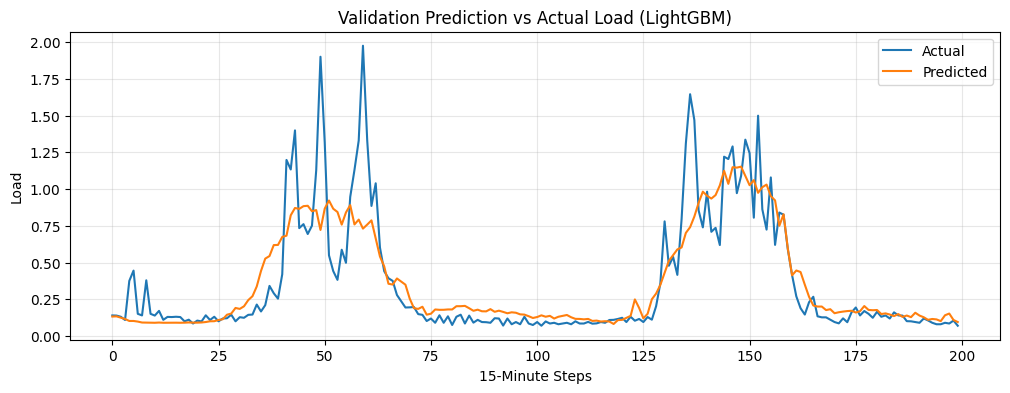

In [ ]:
# ------------------------------------------------------------
# 15. Visual Comparison for Best Single-Step Model
# ------------------------------------------------------------

best_model_name = results_df.iloc[0]["model"]
best_model = models[best_model_name]

y_val_pred = best_model.predict(X_val)

plt.figure(figsize=(12, 4))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_val_pred[:200], label="Predicted")
plt.title(f"Validation Prediction vs Actual Load ({best_model_name})")
plt.xlabel("15-Minute Steps")
plt.ylabel("Load")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# -------------------------------------------------------
# 16. Build Multi-Step Targets (Next 24 Hours)
# -------------------------------------------------------

horizon = 96  # 24 hours ahead (15-min resolution)

y_multi = pd.DataFrame(index=df_house_pre_cutoff.index)

for h in range(1, horizon + 1):
    y_multi[f"target_t+{h}"] = df_house_pre_cutoff["load"].shift(-h)

display(y_multi.head())

,target_t+1,target_t+2,target_t+3,target_t+4,target_t+5,target_t+6,target_t+7,target_t+8,target_t+9,target_t+10,...,target_t+87,target_t+88,target_t+89,target_t+90,target_t+91,target_t+92,target_t+93,target_t+94,target_t+95,target_t+96
timestamp,,,,,,,,,,,,,,,,,,,,,
2024-07-20 15:45:00+00:00,0.431,0.431,0.381,0.227,0.241,0.267,0.242,0.204,0.146,0.133,...,0.838,0.891,0.921,0.780,0.711,0.677,0.644,0.575,0.488,0.426
2024-07-20 16:00:00+00:00,0.431,0.381,0.227,0.241,0.267,0.242,0.204,0.146,0.133,0.144,...,0.891,0.921,0.780,0.711,0.677,0.644,0.575,0.488,0.426,0.451
2024-07-20 16:15:00+00:00,0.381,0.227,0.241,0.267,0.242,0.204,0.146,0.133,0.144,0.263,...,0.921,0.780,0.711,0.677,0.644,0.575,0.488,0.426,0.451,0.440
2024-07-20 16:30:00+00:00,0.227,0.241,0.267,0.242,0.204,0.146,0.133,0.144,0.263,0.130,...,0.780,0.711,0.677,0.644,0.575,0.488,0.426,0.451,0.440,0.366
2024-07-20 16:45:00+00:00,0.241,0.267,0.242,0.204,0.146,0.133,0.144,0.263,0.130,0.157,...,0.711,0.677,0.644,0.575,0.488,0.426,0.451,0.440,0.366,0.312


In [ ]:
# --------------------------------------------------------
# 17. Align Features and Multi-Step Targets
# --------------------------------------------------------

data_multi = pd.concat([X, y_multi], axis=1).dropna()

print("Aligned multi-step dataset shape:", data_multi.shape)

Aligned multi-step dataset shape: (59457, 136)


In [ ]:
# ---------------------------------------------------
# 18. Separate Multi-Step Inputs and Targets
# ---------------------------------------------------
# --- FIX: enforce cutoff (NO leakage) ---
data_multi = data_multi[data_multi.index <= cutoff_date]

X_multi = data_multi[X.columns].copy()
y_multi = data_multi[[col for col in data_multi.columns if col.startswith("target_t+")]].copy()

print("X_multi shape:", X_multi.shape)
print("y_multi shape:", y_multi.shape)

X_multi shape: (59457, 40)
y_multi shape: (59457, 96)


In [ ]:
# ---------------------------------------------------------
# 19. Chronological Train / Validation Split for Multi-Step Forecasting
# ---------------------------------------------------------

n = len(X_multi)

train_end = int(n * 0.80)

X_train = X_multi.iloc[:train_end]
y_train = y_multi.iloc[:train_end]

X_val = X_multi.iloc[train_end:]
y_val = y_multi.iloc[train_end:]

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Train end:", X_train.index.max())
print("Validation start:", X_val.index.min())

Train: (47565, 40) (47565, 96)
Validation: (11892, 40) (11892, 96)
Train end: 2025-11-28 02:45:00+00:00
Validation start: 2025-11-28 03:00:00+00:00


In [ ]:
# ---------------------------------------------------------
# 20. Train Multi-Output LightGBM Model
# ---------------------------------------------------------

multi_lgbm = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=100,
        random_state=42
    )
)

multi_lgbm.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003765 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8017
[LightGBM] [Info] Number of data points in the train set: 47565, number of used features: 40
[LightGBM] [Info] Start training from score 0.447505
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005370 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8017
[LightGBM] [Info] Number of data points in the train set: 47565, number of used features: 40
[LightGBM] [Info] Start training from score 0.447497
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004084 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8017
[LightGBM] [Info] Number of data points in the train set: 47565, number of used features: 40
[LightGBM] [Info] Start tra

MultiOutputRegressor(estimator=LGBMRegressor(random_state=42))

In [ ]:
# ---------------------------------------------------------
# 21. Generate Validation Forecasts
# ---------------------------------------------------------

y_val_pred = multi_lgbm.predict(X_val)

print("Validation prediction shape:", y_val_pred.shape)

Validation prediction shape: (11892, 96)


In [ ]:
# ---------------------------------------------------------
# 22. Evaluate Multi-Step Performance
# ---------------------------------------------------------

mae = mean_absolute_error(y_val.values.flatten(), y_val_pred.flatten())
rmse = np.sqrt(mean_squared_error(y_val.values.flatten(), y_val_pred.flatten()))

print("Validation MAE:", mae)
print("Validation RMSE:", rmse)

Validation MAE: 0.11346289515909556
Validation RMSE: 0.1991673356293563


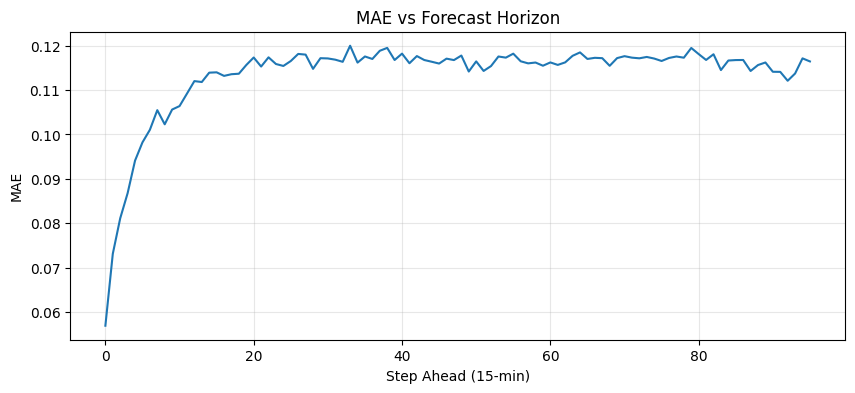

In [ ]:
# ---------------------------------------------------------
# 23. MAE per Forecast Horizon
# ---------------------------------------------------------

mae_per_step = []

for h in range(horizon):
    mae_h = mean_absolute_error(y_val.iloc[:, h], y_val_pred[:, h])
    mae_per_step.append(mae_h)

plt.figure(figsize=(10, 4))
plt.plot(mae_per_step)
plt.title("MAE vs Forecast Horizon")
plt.xlabel("Step Ahead (15-min)")
plt.ylabel("MAE")
plt.grid(alpha=0.3)
plt.show()

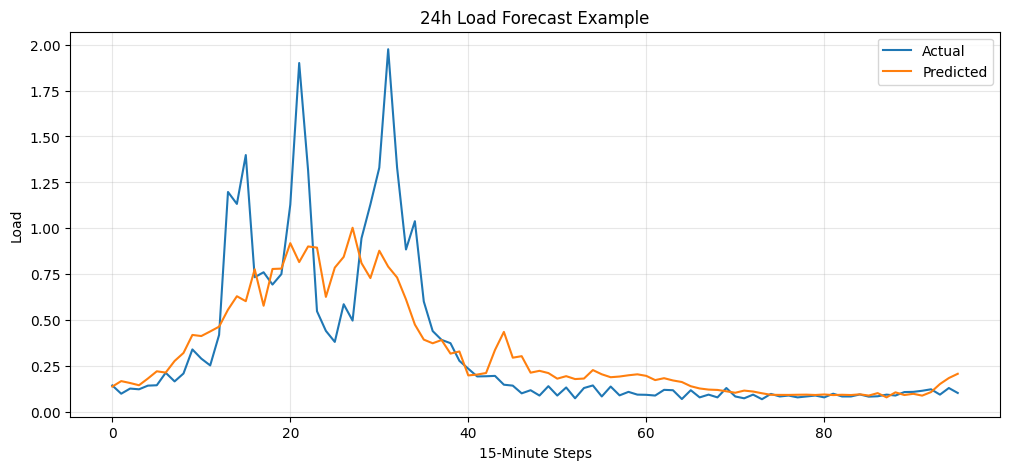

In [ ]:
# ---------------------------------------------------------
# 24. Example 24h Forecast
# ---------------------------------------------------------

sample = 200

plt.figure(figsize=(12, 5))
plt.plot(y_val.iloc[sample].values, label="Actual")
plt.plot(y_val_pred[sample], label="Predicted")

plt.title("24h Load Forecast Example")
plt.xlabel("15-Minute Steps")
plt.ylabel("Load")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [ ]:
# ---------------------------------------------------------
# 25. Define Hyperparameter Search Space
# ---------------------------------------------------------

param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 5, 10, 15],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.0, 0.1, 0.5],
    "reg_lambda": [0.0, 0.1, 0.5, 1.0],
}

In [ ]:
# ---------------------------------------------------------
# 26. Randomized Hyperparameter Tuning
# ---------------------------------------------------------

random.seed(42)

all_param_combinations = list(itertools.product(
    param_grid["n_estimators"],
    param_grid["learning_rate"],
    param_grid["num_leaves"],
    param_grid["max_depth"],
    param_grid["min_child_samples"],
    param_grid["subsample"],
    param_grid["colsample_bytree"],
    param_grid["reg_alpha"],
    param_grid["reg_lambda"],
))

print("Total possible combinations:", len(all_param_combinations))

n_trials = 20
sampled_combinations = random.sample(
    all_param_combinations,
    min(n_trials, len(all_param_combinations))
)

tuning_results = []

for i, combo in enumerate(sampled_combinations, start=1):
    params = {
        "n_estimators": combo[0],
        "learning_rate": combo[1],
        "num_leaves": combo[2],
        "max_depth": combo[3],
        "min_child_samples": combo[4],
        "subsample": combo[5],
        "colsample_bytree": combo[6],
        "reg_alpha": combo[7],
        "reg_lambda": combo[8],
    }

    print(f"Running config {i}/{len(sampled_combinations)}")
    print(params)

    model = MultiOutputRegressor(
        LGBMRegressor(
            random_state=42,
            verbosity=-1,
            **params
        )
    )

    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val.values.flatten(), y_val_pred.flatten())
    rmse = np.sqrt(mean_squared_error(y_val.values.flatten(), y_val_pred.flatten()))

    row = params.copy()
    row["MAE"] = mae
    row["RMSE"] = rmse
    tuning_results.append(row)

tuning_results_df = (
    pd.DataFrame(tuning_results)
    .sort_values("RMSE")
    .reset_index(drop=True)
)

display(tuning_results_df.head(10))

Total possible combinations: 196608
Running config 1/20
{'n_estimators': 500, 'learning_rate': 0.03, 'num_leaves': 63, 'max_depth': 10, 'min_child_samples': 20, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.1, 'reg_lambda': 0.1}
Running config 2/20
{'n_estimators': 100, 'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': 10, 'min_child_samples': 10, 'subsample': 0.7, 'colsample_bytree': 0.7, 'reg_alpha': 0.0, 'reg_lambda': 0.0}
Running config 3/20
{'n_estimators': 100, 'learning_rate': 0.01, 'num_leaves': 63, 'max_depth': -1, 'min_child_samples': 30, 'subsample': 0.7, 'colsample_bytree': 0.9, 'reg_alpha': 0.1, 'reg_lambda': 0.0}
Running config 4/20
{'n_estimators': 500, 'learning_rate': 0.1, 'num_leaves': 127, 'max_depth': 5, 'min_child_samples': 10, 'subsample': 0.8, 'colsample_bytree': 1.0, 'reg_alpha': 0.1, 'reg_lambda': 0.1}
Running config 5/20
{'n_estimators': 200, 'learning_rate': 0.03, 'num_leaves': 127, 'max_depth': 5, 'min_child_samples': 50, 'subsample': 0.9, 'c

,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,reg_alpha,reg_lambda,MAE,RMSE
0,200,0.03,127,5,50,0.9,0.7,0.0,0.1,0.111508,0.194691
1,500,0.01,63,5,30,0.7,1.0,0.1,0.5,0.111619,0.195076
2,200,0.03,15,15,30,0.8,0.8,0.5,0.0,0.113626,0.195964
3,100,0.05,15,10,50,1.0,1.0,0.0,0.0,0.114207,0.196171
4,100,0.05,31,10,10,0.7,0.7,0.0,0.0,0.112577,0.196312
5,300,0.03,15,-1,10,0.7,0.8,0.0,0.0,0.113504,0.196516
6,100,0.03,127,5,30,0.9,1.0,0.0,0.5,0.117688,0.196726
7,500,0.03,63,10,20,0.7,0.7,0.1,0.1,0.112978,0.199161
8,100,0.05,127,15,30,0.9,0.7,0.0,1.0,0.111930,0.199234
9,500,0.05,31,10,50,1.0,0.9,0.5,0.0,0.113851,0.199987


In [ ]:
# ---------------------------------------------------------
# 27. Retrain Final Model on Full Pre-Cutoff Data
# ---------------------------------------------------------

best_params = {
    "n_estimators": 200,
    "learning_rate": 0.03,
    "num_leaves": 127,
    "max_depth": 5,
    "min_child_samples": 50,
    "subsample": 0.9,
    "colsample_bytree": 0.7,
    "reg_alpha": 0.0,
    "reg_lambda": 0.1,
}

final_model = MultiOutputRegressor(
    LGBMRegressor(
        random_state=42,
        verbosity=-1,
        **best_params
    )
)
# --- SAFETY CHECK ---
assert X_multi.index.max() <= cutoff_date, "Leakage detected!"
assert y_multi.index.max() <= cutoff_date, "Leakage detected!"
final_model.fit(X_multi, y_multi)

MultiOutputRegressor(estimator=LGBMRegressor(colsample_bytree=0.7,
                                             learning_rate=0.03, max_depth=5,
                                             min_child_samples=50,
                                             n_estimators=200, num_leaves=127,
                                             random_state=42, reg_lambda=0.1,
                                             subsample=0.9, verbosity=-1))

In [ ]:
# ---------------------------------------------------------
# 28. Save Final Model
# ---------------------------------------------------------

joblib.dump({
    "model": final_model,
    "feature_cols": X.columns.tolist()
}, "../models/load_forecast_model.pkl")

['../models/load_forecast_model.pkl']

In [ ]:
# ---------------------------------------------------------
# 29. Build Next 24h Forecast Table from Stored Dataset
# ---------------------------------------------------------

def build_next_24h_load_table_from_dataset(
    model,
    df_all,
    forecast_time,
    feature_cols,
    household_name="residential1"
):
    df_all = df_all.copy()
    df_all.index = pd.to_datetime(df_all.index, utc=True)
    df_all = df_all.sort_index()

    forecast_time = pd.Timestamp(forecast_time)

    if forecast_time.tzinfo is None:
        forecast_time = forecast_time.tz_localize("UTC")
    else:
        forecast_time = forecast_time.tz_convert("UTC")

    if forecast_time not in df_all.index:
        raise ValueError(f"forecast_time {forecast_time} not found in dataset index")

    df_hist = df_all.loc[df_all.index < forecast_time, ["load"]].copy()

    # --- FIX: ensure no gaps ---
    df_hist = df_hist.asfreq("15min")
    df_hist["load"] = df_hist["load"].ffill()

    if len(df_hist) < 192:
        raise ValueError("Not enough history before forecast_time for lag_192")

    row_at_forecast = df_all.loc[[forecast_time]].copy()

    feature_row = {}

    de_holidays = holidays.Germany()

    feature_row["hour"] = forecast_time.hour
    feature_row["day_of_week"] = forecast_time.dayofweek
    feature_row["month"] = forecast_time.month
    feature_row["is_weekend"] = int(forecast_time.dayofweek >= 5)
    feature_row["is_holiday"] = int(
        forecast_time.tz_localize(None).normalize() in de_holidays
    )

    feature_row["lag_1"] = df_hist["load"].iloc[-1]
    feature_row["lag_2"] = df_hist["load"].iloc[-2]
    feature_row["lag_3"] = df_hist["load"].iloc[-3]
    feature_row["lag_96"] = df_hist["load"].iloc[-96]
    feature_row["lag_192"] = df_hist["load"].iloc[-192]

    feature_row["delta_1"] = df_hist["load"].iloc[-1] - df_hist["load"].iloc[-2]
    feature_row["delta_2"] = df_hist["load"].iloc[-2] - df_hist["load"].iloc[-3]
    feature_row["rolling_std_1h"] = df_hist["load"].iloc[-4:].std()

    feature_row["rolling_mean_1h"] = df_hist["load"].iloc[-4:].mean()
    feature_row["rolling_mean_24h"] = df_hist["load"].iloc[-96:].mean()

    for col in weather_feature_cols:
        if col not in row_at_forecast.columns:
            raise ValueError(f"Missing weather feature: {col}")
        feature_row[col] = row_at_forecast.iloc[0][col]

    X_latest = pd.DataFrame([feature_row])[feature_cols]

    y_pred = model.predict(X_latest).flatten()

    future_times = pd.date_range(
        start=forecast_time,
        periods=96,
        freq="15min",
        tz="UTC"
    )

    forecast_table = pd.DataFrame({
        "time": future_times,
        "predicted_kwh": np.round(y_pred, 4),
        "predicted_kw": np.round(y_pred * 4, 4),
        "household": household_name,
        "source": "historical_simulation_forecast"
    })

    return forecast_table

In [ ]:
# ---------------------------------------------------------
# 30. Run Example Forecast
# ---------------------------------------------------------

bundle = joblib.load("../models/load_forecast_model.pkl")
model = bundle["model"]
feature_cols = bundle["feature_cols"]

forecast_time = "2026-04-07 00:00:00+00:00"

forecast_table = build_next_24h_load_table_from_dataset(
    model=final_model,
    df_all=df_house,
    forecast_time=forecast_time,
    feature_cols=feature_cols,
    household_name="residential1"
)

display(forecast_table.head(12))
print(forecast_table.shape)

,time,predicted_kwh,predicted_kw,household,source
0,2026-04-07 00:00:00+00:00,0.1060,0.4240,residential1,historical_simulation_forecast
1,2026-04-07 00:15:00+00:00,0.1113,0.4451,residential1,historical_simulation_forecast
2,2026-04-07 00:30:00+00:00,0.1048,0.4191,residential1,historical_simulation_forecast
3,2026-04-07 00:45:00+00:00,0.1081,0.4325,residential1,historical_simulation_forecast
4,2026-04-07 01:00:00+00:00,0.1022,0.4087,residential1,historical_simulation_forecast
5,2026-04-07 01:15:00+00:00,0.1017,0.4068,residential1,historical_simulation_forecast
6,2026-04-07 01:30:00+00:00,0.0987,0.3948,residential1,historical_simulation_forecast
7,2026-04-07 01:45:00+00:00,0.1006,0.4024,residential1,historical_simulation_forecast
8,2026-04-07 02:00:00+00:00,0.0986,0.3944,residential1,historical_simulation_forecast
9,2026-04-07 02:15:00+00:00,0.1025,0.4100,residential1,historical_simulation_forecast


(96, 5)


In [ ]:
# ---------------------------------------------------------
# 31. Save Forecast Output
# ---------------------------------------------------------

forecast_output_path = "../data/load_forecast_residential1_2026-04-07.csv"

forecast_table.to_csv(forecast_output_path, index=False)

print("Saved forecast to:", forecast_output_path)

Saved forecast to: ../data/load_forecast_residential1_2026-04-07.csv
